# 02 - Exploratory Data Analysis

This notebook explores the cleaned Eurostat energy data through SQL queries and visualisations.
The goal is to understand the overall shape of the data before moving to time series analysis in notebook 03.

**Steps:**
1. Connect to the database
2. Database overview — confirm tables, row counts, year range
3. EU-level energy trends — how has total energy availability changed over time?
4. Energy dependency rate — which countries import most of their energy?
5. Fossil fuel breakdown — how does the fossil fuel mix (gas, oil, coal) look across the EU?
6. Renewables growth — how has the renewable share evolved?
7. Country comparison — ranking countries by dependency rate and renewable share (latest year)

In [36]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from utils.config import DB_PATH, TABLE_NAMES

sns.set_theme(style='whitegrid')
conn = sqlite3.connect(DB_PATH)

## 1. Database Overview

Confirming what's in the database — tables, row counts, year range, and country list.

In [37]:
for table in TABLE_NAMES.values():
    row_amount = pd.read_sql(f"SELECT COUNT(*) as total FROM {table}", conn)['total'][0]
    year_range = pd.read_sql(f"SELECT MIN(year) as min_year, MAX(year) as max_year FROM {table}", conn)
    min_year = year_range['min_year'][0]
    max_year = year_range['max_year'][0]
    columns = pd.read_sql(f"PRAGMA table_info({table})", conn)['name'].tolist()
    countries = pd.read_sql(f"SELECT DISTINCT country FROM {table} ORDER BY country", conn)['country'].tolist()
    print(f"\nTable '{table}' — {row_amount} rows | {min_year}-{max_year}")
    print(f"Countries ({len(countries)}): {countries}")
    print(f"Columns: {columns}")


Table 'energy_dependency' — 1620 rows | 2005-2024
Countries (27): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']
Columns: ['balance_type', 'energy_source', 'country', 'year', 'value_gwh']

Table 'fossil_fuels' — 6480 rows | 2005-2024
Countries (27): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden']
Columns: ['balance_type', 'energy_source', 'country', 'year', 'value_gwh']

Table 'renewables' — 5400 rows | 2005-2024
Countries (27): ['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechi

In [38]:
for table in TABLE_NAMES.values():
    unique_balance_type_vals = pd.read_sql(f"SELECT DISTINCT balance_type FROM {table} ORDER BY balance_type", conn)['balance_type'].tolist()
    unique_energy_source_vals = pd.read_sql(f"SELECT DISTINCT energy_source FROM {table} ORDER BY energy_source", conn)['energy_source'].tolist()
    print(f"\nTable '{table}'")
    print(f"Unique balance types: {unique_balance_type_vals}")
    print(f"Unique energy sources: {unique_energy_source_vals}")


Table 'energy_dependency'
Unique balance types: ['Exports', 'Gross available energy', 'Imports']
Unique energy sources: ['Total']

Table 'fossil_fuels'
Unique balance types: ['Exports', 'Gross available energy', 'Imports', 'Primary production']
Unique energy sources: ['Natural gas', 'Oil and petroleum products (excluding biofuel portion)', 'Solid fossil fuels']

Table 'renewables'
Unique balance types: ['Gross available energy', 'Primary production']
Unique energy sources: ['Hydro', 'Nuclear heat', 'Renewables and biofuels', 'Solar photovoltaic', 'Wind']


## 2. EU-Level Energy Trends

Aggregating across all 27 countries to see how total gross available energy has changed over time.
A good first look at whether overall EU energy consumption is growing, shrinking, or stable.

In [39]:
total_energy_per_year = pd.read_sql("""
    SELECT year, SUM(value_gwh) as total_gwh
    FROM energy_dependency
    WHERE balance_type = 'Gross available energy'
    GROUP BY year
    ORDER BY year
""", conn).set_index('year')

total_energy_per_year

,total_gwh
year,
2005,1.920102e+07
2006,1.939832e+07
2007,1.918009e+07
2008,1.912768e+07
2009,1.797029e+07
2010,1.868209e+07
2011,1.814961e+07
2012,1.789213e+07
2013,1.769023e+07


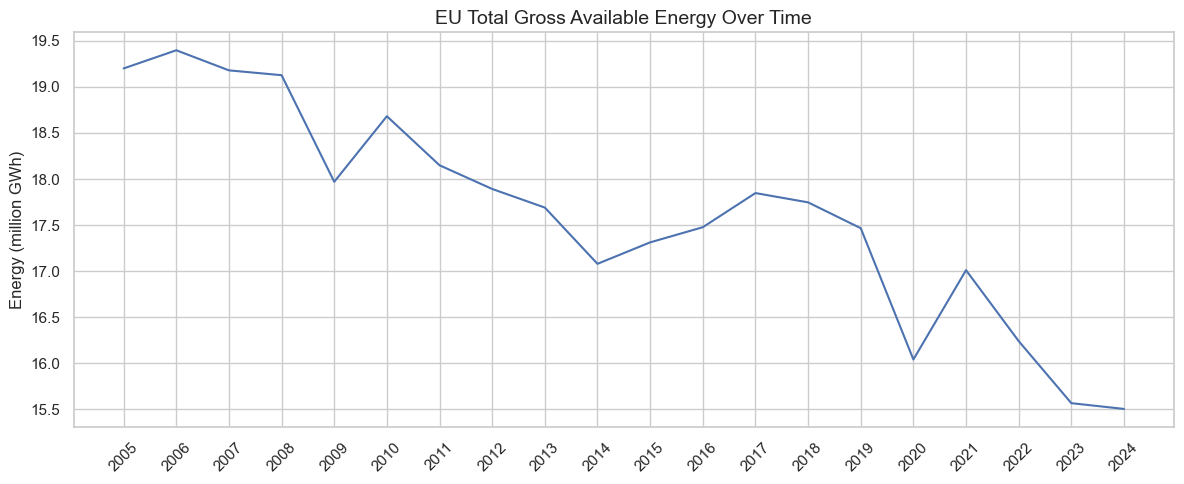

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(total_energy_per_year.index, total_energy_per_year['total_gwh'] / 1_000_000)

ax.set_title('EU Total Gross Available Energy Over Time', fontsize=14)
ax.set_ylabel('Energy (million GWh)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Energy Dependency Rate

Energy dependency rate = `(Imports - Exports) / Gross Available Energy × 100`

A rate above 0% means the country is a net importer. A rate near 100% means almost all energy comes from abroad (e.g. Malta, Luxembourg). A negative rate means the country exports more than it imports (e.g. Denmark historically).

In [41]:
# CASE WHEN lets us pivot the three balance types into columns in a single query
dependency_rate = pd.read_sql("""
    SELECT country, year,
           ROUND(
               (SUM(CASE WHEN balance_type = 'Imports' THEN value_gwh ELSE 0 END) -
                SUM(CASE WHEN balance_type = 'Exports' THEN value_gwh ELSE 0 END)) /
                SUM(CASE WHEN balance_type = 'Gross available energy' THEN value_gwh ELSE 0 END) * 100
           , 1) as dependency_rate
    FROM energy_dependency
    GROUP BY country, year
    ORDER BY country, year
""", conn)

display(dependency_rate.head(10))

,country,year,dependency_rate
0,Austria,2005,71.8
1,Austria,2006,72.2
2,Austria,2007,68.5
3,Austria,2008,68.7
4,Austria,2009,65.1
5,Austria,2010,62.8
6,Austria,2011,70.0
7,Austria,2012,63.8
8,Austria,2013,61.3
9,Austria,2014,65.6


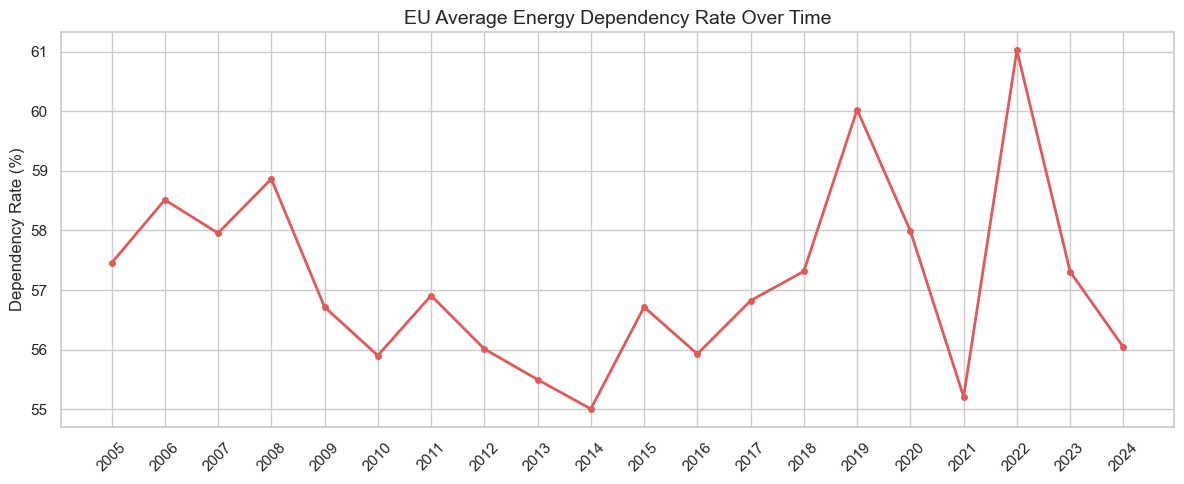

In [42]:
eu_avg_dependency = dependency_rate.groupby('year')['dependency_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(eu_avg_dependency['year'], eu_avg_dependency['dependency_rate'], color='#E05A5A', linewidth=2, marker='o', markersize=4)
ax.set_title('EU Average Energy Dependency Rate Over Time', fontsize=14)
ax.set_ylabel('Dependency Rate (%)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

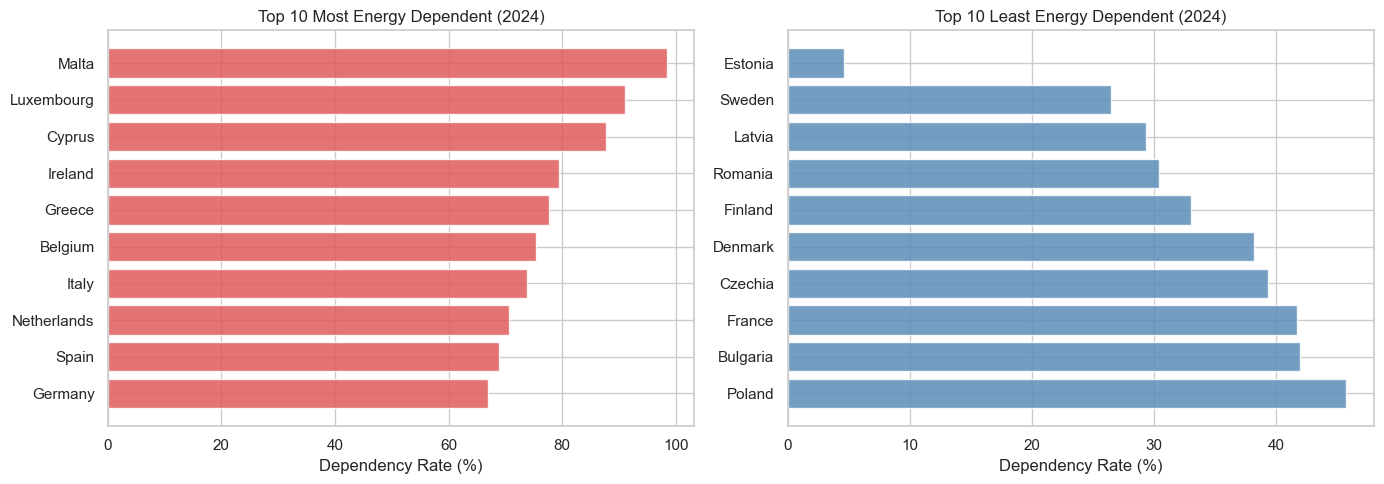

In [43]:
latest_year = dependency_rate['year'].max()
latest = dependency_rate[dependency_rate['year'] == latest_year].sort_values('dependency_rate', ascending=False)

top10 = latest.head(10)
bottom10 = latest.tail(10).sort_values('dependency_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10['country'], top10['dependency_rate'], color='#E05A5A', alpha=0.85)
axes[0].set_title(f'Top 10 Most Energy Dependent ({latest_year})', fontsize=12)
axes[0].set_xlabel('Dependency Rate (%)')
axes[0].invert_yaxis()

axes[1].barh(bottom10['country'], bottom10['dependency_rate'], color='#5B8DB8', alpha=0.85)
axes[1].set_title(f'Top 10 Least Energy Dependent ({latest_year})', fontsize=12)
axes[1].set_xlabel('Dependency Rate (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Fossil Fuel Breakdown

Looking at gross available energy by fossil fuel type (natural gas, oil, coal) across the EU.
Useful to see which fuel dominates and whether the mix is shifting.

In [44]:
fossil_mix = pd.read_sql("""
    SELECT year, energy_source, SUM(value_gwh) / 1000000 as total_gwh_m
    FROM fossil_fuels
    WHERE balance_type = 'Gross available energy'
    GROUP BY year, energy_source
    ORDER BY year, energy_source
""", conn)

display(fossil_mix.head(9))

,year,energy_source,total_gwh_m
0,2005,Natural gas,4.183440
1,2005,Oil and petroleum products (excluding biofuel ...,7.510911
2,2005,Solid fossil fuels,3.189572
3,2006,Natural gas,4.181570
4,2006,Oil and petroleum products (excluding biofuel ...,7.527098
5,2006,Solid fossil fuels,3.277472
6,2007,Natural gas,4.105825
7,2007,Oil and petroleum products (excluding biofuel ...,7.352699
8,2007,Solid fossil fuels,3.288223


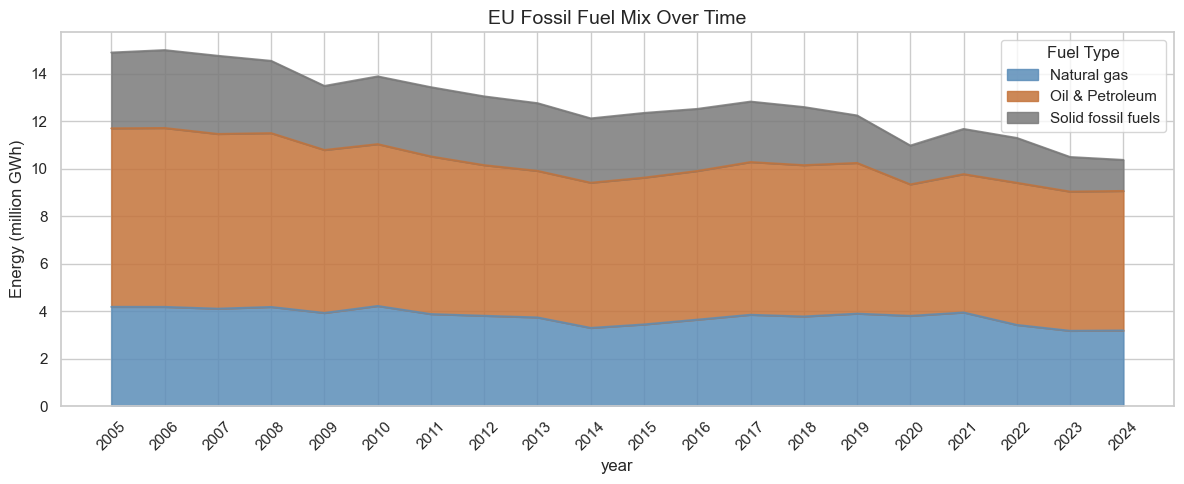

In [45]:
fossil_pivot = fossil_mix.pivot(index='year', columns='energy_source', values='total_gwh_m')

# Shorten the long oil column name for the legend
fossil_pivot = fossil_pivot.rename(columns={
    'Oil and petroleum products (excluding biofuel portion)': 'Oil & Petroleum'
})

# Natural gas, Oil & Petroleum, Solid fossil fuels (alphabetical after rename)
colors = ['#5B8DB8', '#C4733A', '#7A7A7A']

fig, ax = plt.subplots(figsize=(12, 5))
fossil_pivot.plot.area(ax=ax, color=colors, alpha=0.85)
ax.set_title('EU Fossil Fuel Mix Over Time', fontsize=14)
ax.set_ylabel('Energy (million GWh)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

## 5. Renewables Growth

Tracking the rise of renewables across the EU. Using `Renewables and biofuels` for the total,
and `Solar photovoltaic` + `Wind` individually to highlight the fastest-growing sources.

In [ ]:
renewables_trend = pd.read_sql("""
    SELECT year, energy_source, SUM(value_gwh) / 1000000 as total_gwh_m
    FROM renewables
    WHERE balance_type = 'Primary production'
      AND energy_source IN ('Renewables and biofuels', 'Solar photovoltaic', 'Wind', 'Hydro')
    GROUP BY year, energy_source
    ORDER BY year, energy_source
""", conn)

display(renewables_trend.head(8))

,year,energy_source,total_gwh_m
0,2005,Hydro,0.307010
1,2005,Renewables and biofuels,1.375556
2,2005,Solar photovoltaic,0.001459
3,2005,Wind,0.068113
4,2006,Hydro,0.309987
5,2006,Renewables and biofuels,1.457020
6,2006,Solar photovoltaic,0.002489
7,2006,Wind,0.078738


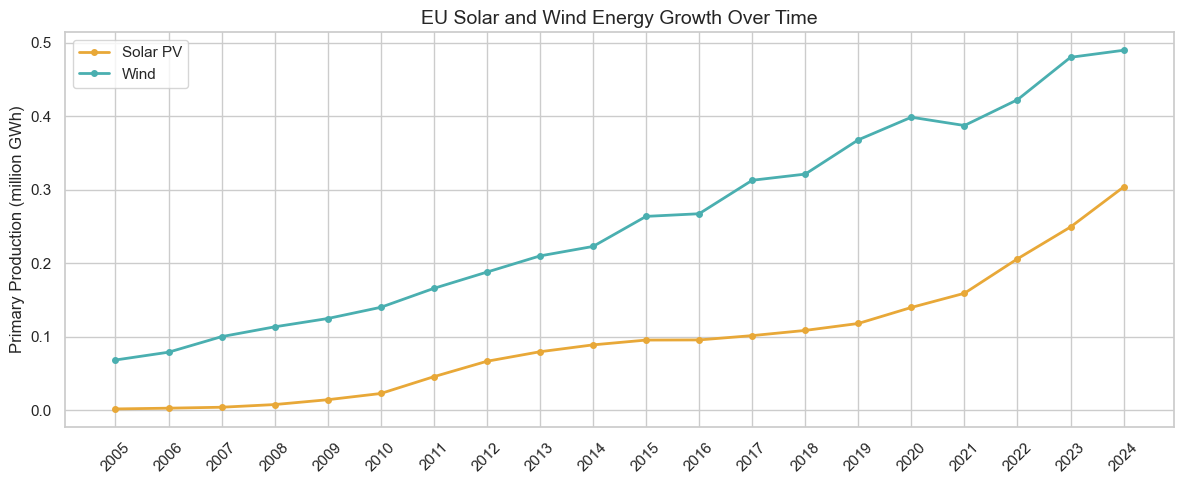

In [47]:
solar_wind = renewables_trend[renewables_trend['energy_source'].isin(['Solar photovoltaic', 'Wind'])]
solar_wind_pivot = solar_wind.pivot(index='year', columns='energy_source', values='total_gwh_m')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(solar_wind_pivot.index, solar_wind_pivot['Solar photovoltaic'], color='#E8A838', linewidth=2, marker='o', markersize=4, label='Solar PV')
ax.plot(solar_wind_pivot.index, solar_wind_pivot['Wind'], color='#4AAFB0', linewidth=2, marker='o', markersize=4, label='Wind')
ax.set_title('EU Solar and Wind Energy Growth Over Time', fontsize=14)
ax.set_ylabel('Primary Production (million GWh)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Country Comparison (Latest Year)

Ranking all 27 countries by two metrics in the most recent year:
- Energy dependency rate
- Renewable share of gross available energy

In [48]:
latest_dependency = pd.read_sql("""
    SELECT country,
           ROUND(
               (SUM(CASE WHEN balance_type = 'Imports' THEN value_gwh ELSE 0 END) -
                SUM(CASE WHEN balance_type = 'Exports' THEN value_gwh ELSE 0 END)) /
                SUM(CASE WHEN balance_type = 'Gross available energy' THEN value_gwh ELSE 0 END) * 100
           , 1) as dependency_rate
    FROM energy_dependency
    WHERE year = (SELECT MAX(year) FROM energy_dependency)
    GROUP BY country
    ORDER BY dependency_rate DESC
""", conn)

display(latest_dependency)

,country,dependency_rate
0,Malta,98.4
1,Luxembourg,91.0
2,Cyprus,87.7
3,Ireland,79.5
4,Greece,77.7
5,Belgium,75.4
6,Italy,73.9
7,Netherlands,70.6
8,Spain,68.9
9,Germany,66.9


In [49]:
# JOIN across two tables: renewables primary production vs total gross available energy
latest_renewable_share = pd.read_sql("""
    SELECT r.country,
           ROUND(SUM(r.value_gwh) / SUM(e.value_gwh) * 100, 1) as renewable_share
    FROM renewables r
    JOIN energy_dependency e
        ON r.country = e.country AND r.year = e.year
    WHERE r.balance_type = 'Primary production'
      AND r.energy_source = 'Renewables and biofuels'
      AND e.balance_type = 'Gross available energy'
      AND r.year = (SELECT MAX(year) FROM renewables)
    GROUP BY r.country
    ORDER BY renewable_share DESC
""", conn)

display(latest_renewable_share)

,country,renewable_share
0,Latvia,69.9
1,Sweden,47.0
2,Estonia,45.4
3,Finland,40.3
4,Austria,39.0
5,Portugal,34.5
6,Denmark,30.6
7,Lithuania,29.9
8,Croatia,27.8
9,Germany,20.0


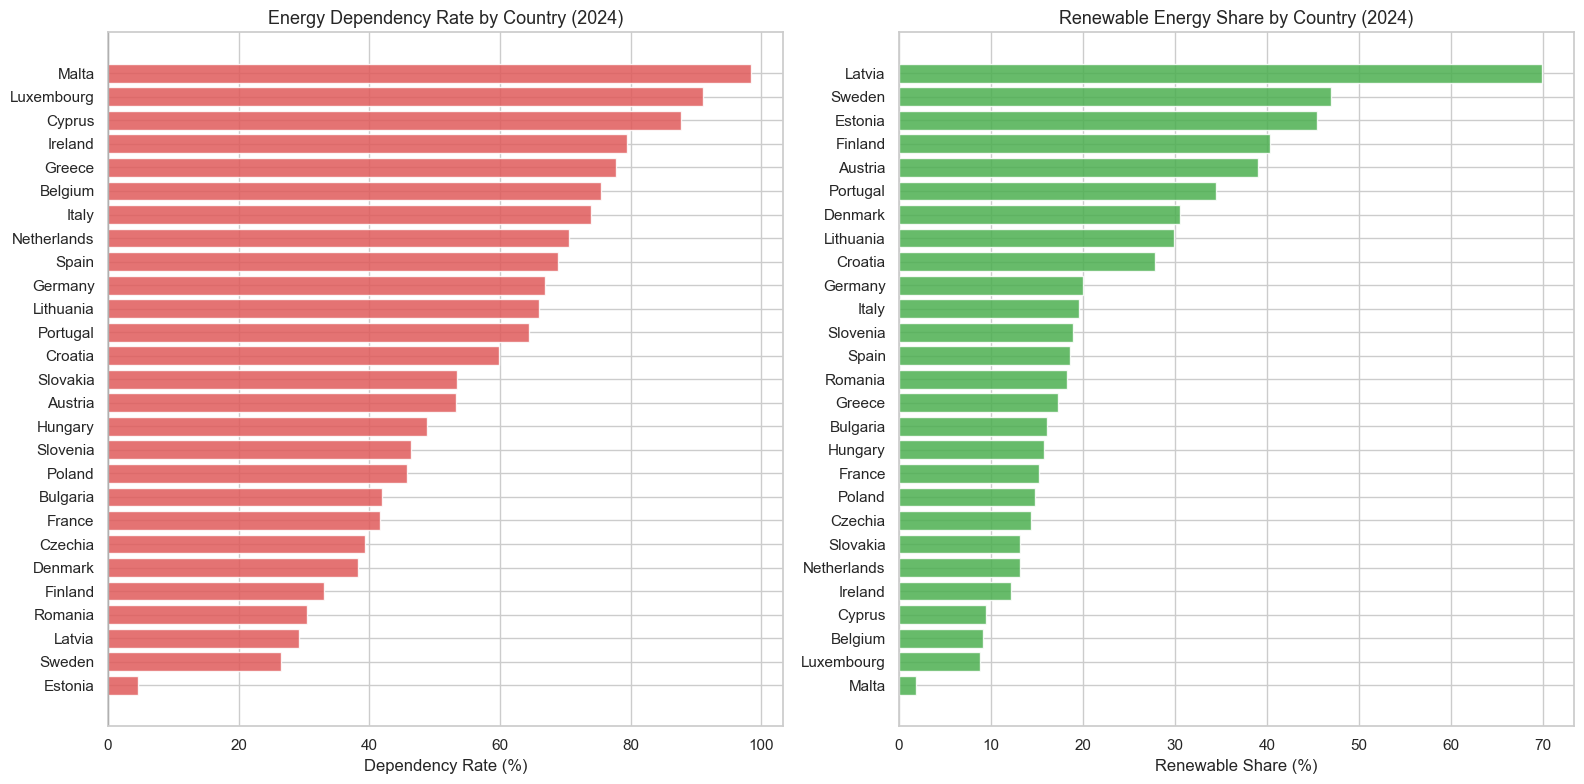

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(latest_dependency['country'], latest_dependency['dependency_rate'], color='#E05A5A', alpha=0.85)
axes[0].set_title(f'Energy Dependency Rate by Country ({latest_year})', fontsize=13)
axes[0].set_xlabel('Dependency Rate (%)')
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].invert_yaxis()

axes[1].barh(latest_renewable_share['country'], latest_renewable_share['renewable_share'], color='#4CAF50', alpha=0.85)
axes[1].set_title(f'Renewable Energy Share by Country ({latest_year})', fontsize=13)
axes[1].set_xlabel('Renewable Share (%)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Nuclear Energy — Phaseouts and Their Impact

Nuclear policy has diverged sharply across the EU over the past 20 years. Four contrasting cases in our dataset:

- **Germany** — deliberate political phaseout across two decades, final reactors closed April 2023. Driven by post-Chernobyl and post-Fukushima public pressure
- **France** — the EU's nuclear powerhouse, supplying ~1.3 million GWh/year consistently. The sharp dip in 2022 was not political — half the fleet was offline simultaneously for corrosion inspections
- **Spain** — policy deadlock: a planned phaseout exists on paper but reactors keep getting lifetime extensions, resulting in a completely flat nuclear output since 2005
- **Italy** — zero nuclear for the entire dataset. Shut everything down after a 1987 post-Chernobyl referendum, which is why Italy carries one of the highest energy dependency rates in the EU (73–85%) throughout the whole period

The key question for Germany and France: **when nuclear changed, what filled the gap?**

In [51]:
nuclear = pd.read_sql("""
    SELECT country, year, ROUND(value_gwh / 1000000, 3) as value_twh
    FROM renewables
    WHERE energy_source = 'Nuclear heat'
      AND balance_type = 'Gross available energy'
    ORDER BY country, year
""", conn)

# Countries that ever had meaningful nuclear production
nuclear_countries = nuclear[nuclear['value_twh'] > 0]['country'].unique()
nuclear_active = nuclear[nuclear['country'].isin(nuclear_countries)]
nuclear_pivot = nuclear_active.pivot(index='year', columns='country', values='value_twh')

display(nuclear_pivot)

country,Belgium,Bulgaria,Czechia,Finland,France,Germany,Hungary,Lithuania,Netherlands,Romania,Slovakia,Slovenia,Spain,Sweden
year,,,,,,,,,,,,,,
2005,0.143,0.056,0.075,0.070,1.355,0.489,0.042,0.033,0.012,0.017,0.055,0.018,0.173,0.217
2006,0.140,0.059,0.079,0.069,1.351,0.502,0.041,0.028,0.010,0.017,0.056,0.017,0.180,0.201
2007,0.145,0.045,0.079,0.070,1.319,0.422,0.044,0.031,0.013,0.023,0.048,0.017,0.165,0.201
2008,0.137,0.048,0.080,0.069,1.318,0.445,0.045,0.031,0.013,0.034,0.052,0.019,0.177,0.192
2009,0.138,0.045,0.081,0.067,1.243,0.404,0.045,0.034,0.011,0.035,0.044,0.016,0.160,0.150
2010,0.135,0.045,0.083,0.065,1.298,0.421,0.046,0.000,0.011,0.034,0.045,0.016,0.188,0.169
2011,0.136,0.048,0.084,0.065,1.340,0.323,0.046,0.000,0.011,0.035,0.047,0.017,0.175,0.177
2012,0.114,0.047,0.089,0.064,1.289,0.298,0.046,0.000,0.011,0.035,0.047,0.015,0.186,0.182
2013,0.120,0.043,0.090,0.066,1.284,0.291,0.045,0.000,0.008,0.034,0.048,0.015,0.172,0.186


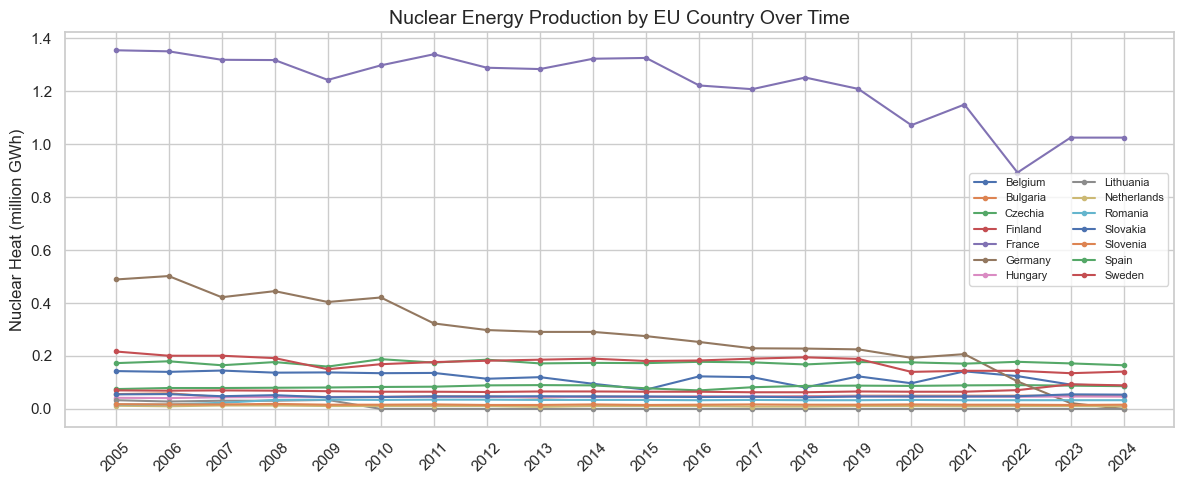

In [52]:
# Show all nuclear countries over time
fig, ax = plt.subplots(figsize=(12, 5))
for country in nuclear_pivot.columns:
    ax.plot(nuclear_pivot.index, nuclear_pivot[country], marker='o', markersize=3, linewidth=1.5, label=country)

ax.set_title('Nuclear Energy Production by EU Country Over Time', fontsize=14)
ax.set_ylabel('Nuclear Heat (million GWh)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.xticks(rotation=45)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

### Germany: What Filled the Nuclear Gap?

Germany reduced nuclear from 0.50 to 0.00 million GWh between 2005 and 2024.
We compare it against fossil fuel imports, renewable production, and dependency rate to see what actually replaced it.

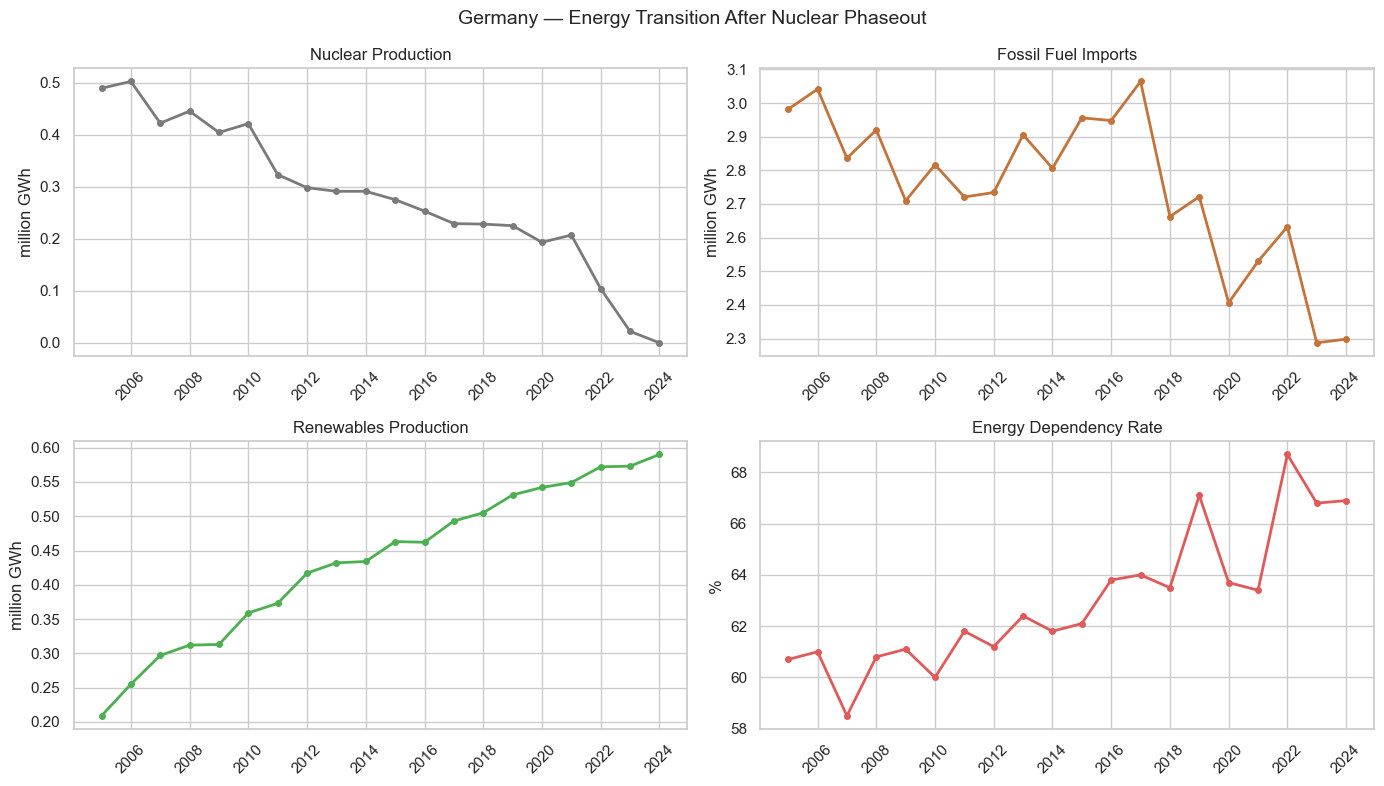

In [53]:
germany_nuclear = pd.read_sql("""
    SELECT year, ROUND(value_gwh / 1000000, 3) as nuclear_twh
    FROM renewables
    WHERE country = 'Germany'
      AND energy_source = 'Nuclear heat'
      AND balance_type = 'Gross available energy'
    ORDER BY year
""", conn)

germany_fossils = pd.read_sql("""
    SELECT year, SUM(value_gwh) / 1000000 as fossil_imports_twh
    FROM fossil_fuels
    WHERE country = 'Germany'
      AND balance_type = 'Imports'
    GROUP BY year ORDER BY year
""", conn)

germany_renewables = pd.read_sql("""
    SELECT year, ROUND(value_gwh / 1000000, 3) as renewables_twh
    FROM renewables
    WHERE country = 'Germany'
      AND energy_source = 'Renewables and biofuels'
      AND balance_type = 'Primary production'
    ORDER BY year
""", conn)

germany_dep = dependency_rate[dependency_rate['country'] == 'Germany'][['year', 'dependency_rate']]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Germany — Energy Transition After Nuclear Phaseout', fontsize=14)

axes[0, 0].plot(germany_nuclear['year'], germany_nuclear['nuclear_twh'], color='#7A7A7A', linewidth=2, marker='o', markersize=4)
axes[0, 0].set_title('Nuclear Production')
axes[0, 0].set_ylabel('million GWh')
axes[0, 0].xaxis.set_major_locator(mticker.MultipleLocator(2))

axes[0, 1].plot(germany_fossils['year'], germany_fossils['fossil_imports_twh'], color='#C4733A', linewidth=2, marker='o', markersize=4)
axes[0, 1].set_title('Fossil Fuel Imports')
axes[0, 1].set_ylabel('million GWh')
axes[0, 1].xaxis.set_major_locator(mticker.MultipleLocator(2))

axes[1, 0].plot(germany_renewables['year'], germany_renewables['renewables_twh'], color='#4CAF50', linewidth=2, marker='o', markersize=4)
axes[1, 0].set_title('Renewables Production')
axes[1, 0].set_ylabel('million GWh')
axes[1, 0].xaxis.set_major_locator(mticker.MultipleLocator(2))

axes[1, 1].plot(germany_dep['year'], germany_dep['dependency_rate'], color='#E05A5A', linewidth=2, marker='o', markersize=4)
axes[1, 1].set_title('Energy Dependency Rate')
axes[1, 1].set_ylabel('%')
axes[1, 1].xaxis.set_major_locator(mticker.MultipleLocator(2))

for ax in axes.flat:
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### France: The 2022 Nuclear Crisis

France kept nuclear stable for most of the period — until 2022, when half the fleet went offline simultaneously for corrosion inspections.
This caused an unexpected energy crunch and pushed France's dependency rate up sharply, despite no political phaseout decision.

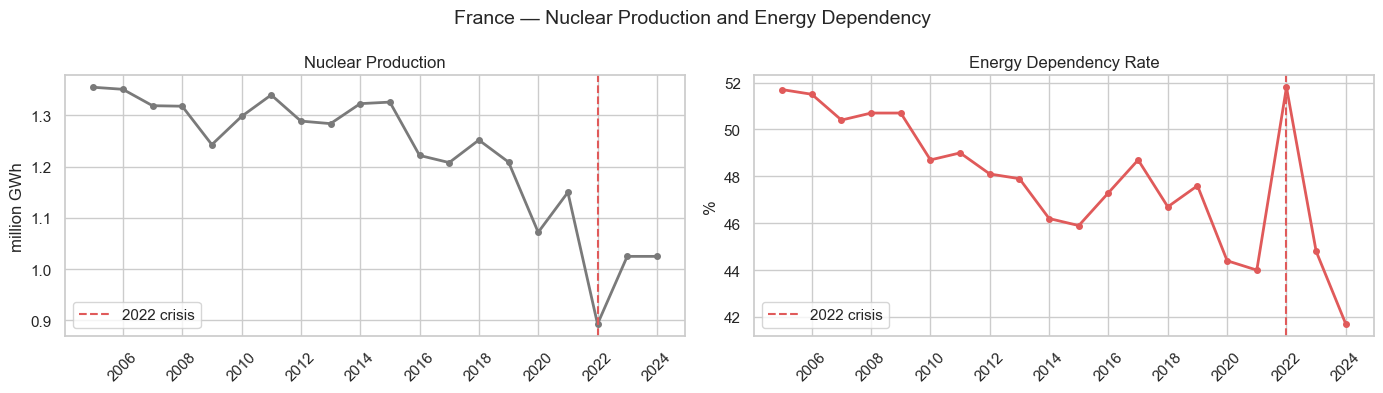

In [54]:
france_nuclear = pd.read_sql("""
    SELECT year, ROUND(value_gwh / 1000000, 3) as nuclear_twh
    FROM renewables
    WHERE country = 'France'
      AND energy_source = 'Nuclear heat'
      AND balance_type = 'Gross available energy'
    ORDER BY year
""", conn)

france_dep = dependency_rate[dependency_rate['country'] == 'France'][['year', 'dependency_rate']]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('France — Nuclear Production and Energy Dependency', fontsize=14)

axes[0].plot(france_nuclear['year'], france_nuclear['nuclear_twh'], color='#7A7A7A', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Nuclear Production')
axes[0].set_ylabel('million GWh')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(2))
axes[0].axvline(x=2022, color='#E05A5A', linestyle='--', linewidth=1.5, label='2022 crisis')
axes[0].legend()

axes[1].plot(france_dep['year'], france_dep['dependency_rate'], color='#E05A5A', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Energy Dependency Rate')
axes[1].set_ylabel('%')
axes[1].xaxis.set_major_locator(mticker.MultipleLocator(2))
axes[1].axvline(x=2022, color='#E05A5A', linestyle='--', linewidth=1.5, label='2022 crisis')
axes[1].legend()

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

conn.close()

## Summary

**Key findings from the EDA:**

1. **EU energy consumption has been in long-term decline.** Total gross available energy fell from 19.2 to 15.5 million GWh between 2005 and 2024 — a 19% drop driven by efficiency improvements and the shift towards a services economy, not just the COVID dip in 2020.

2. **The 2022 energy crisis is visible in the data.** The average EU dependency rate spiked to 61.0% in 2022 — the highest in the dataset — as Russia cut gas supplies following the invasion of Ukraine. By 2024 it had fallen back to 56%, suggesting rapid adaptation through alternative suppliers and demand reduction.

3. **Wind and solar have grown dramatically but from a small base.** EU-wide wind production grew 7x (from 70,000 to 490,000 GWh) between 2005 and 2024. Solar went from near zero to 300,000 GWh, with most of the growth happening after 2015.

4. **Malta is the EU's most extreme case on both metrics.** 98.4% energy dependency rate AND only 1.9% renewable share — both driven by the same cause: island geography with no land borders, no rivers for hydro, and limited space for large-scale wind or solar.

5. **Baltic and Nordic countries lead the transition.** Latvia (69.9%), Sweden (47.0%), and Estonia (45.4%) have the highest renewable shares. Estonia also has the lowest dependency rate at 4.6%, largely due to significant domestic oil shale production.

6. **Germany's nuclear phaseout was partially offset by renewables, but dependency still rose.** Renewables grew from 0.21 to 0.59 million GWh (+180%) across the phaseout period, while fossil fuel imports actually declined. Yet the dependency rate rose from 60.7% to 66.9% — because nuclear was domestic production, and renewables did not grow fast enough to replace it fully.

7. **France shows how directly nuclear capacity drives dependency rate.** France maintained ~50% or lower dependency throughout the period thanks to stable nuclear output. In 2022, when half the French fleet went offline for corrosion inspections, the dependency rate immediately spiked from 44% to 52% — then recovered to 42% in 2024 as reactors came back online, the lowest in the entire dataset for France.